# Лабораторная работа №1: Разведочный анализ данных и визуализация

###### Цель работы: изучение различных методов визуализации данных, построение основных графиков этапа EDA (Exploratory Data Analysis).

# 1. Описание набора данных

В качестве набора данных выбран Diabetes dataset из библиотеки scikit-learn.

age - Возраст в годах (нормализованный)

sex - Пол (бинарный признак)

bmi - Индекс массы тела

bp - Среднее артериальное давление

s1 - TC — общий холестерин в сыворотке крови

s2 - LDL — липопротеины низкой плотности

s3 - HDL — липопротеины высокой плотности

s4 - TC/HDL — отношение общего холестерина к HDL

s5 - LTG — логарифм уровня триглицеридов

s6 - Glu — уровень глюкозы в крови

target - Количественный показатель прогрессирования заболевания через год после базового измерения

# 2. Импорт библиотек и загрузка данных

In [1]:
# Импорт необходимых библиотек
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_diabetes

# Настройка визуализации
%matplotlib inline
sns.set(style="ticks", palette="deep", font_scale=1.1)
plt.rcParams['figure.figsize'] = (10, 6)

In [2]:
# Загрузка датасета
diabetes = load_diabetes()

# Преобразование в DataFrame
df = pd.DataFrame(
    data=np.c_[diabetes['data'], diabetes['target']],
    columns=diabetes['feature_names'] + ['target']
)

# Просмотр первых строк
df.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


In [3]:
# Проверка типа объекта и структуры данных
print(f"Тип объекта: {type(diabetes)}")
print(f"Размер датасета: {df.shape}")
print(f"Имена признаков: {list(df.columns)}")

Тип объекта: <class 'sklearn.utils._bunch.Bunch'>
Размер датасета: (442, 11)
Имена признаков: ['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6', 'target']


# 3. Основные характеристики датасета

### Статистическое описание

In [4]:
# Основные статистики
df.describe().round(3)

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
count,442.000,442.000,442.000,442.000,442.000,442.000,442.000,442.000,442.000,442.000,442.000
mean,-0.000,0.000,-0.000,-0.000,-0.000,0.000,-0.000,-0.000,0.000,0.000,152.133
std,0.048,0.048,0.048,0.048,0.048,0.048,0.048,0.048,0.048,0.048,77.093
min,-0.107,-0.045,-0.090,-0.112,-0.127,-0.116,-0.102,-0.076,-0.126,-0.138,25.000
25%,-0.037,-0.045,-0.034,-0.037,-0.034,-0.030,-0.035,-0.039,-0.033,-0.033,87.000
50%,0.005,-0.045,-0.007,-0.006,-0.004,-0.004,-0.007,-0.003,-0.002,-0.001,140.500
75%,0.038,0.051,0.031,0.036,0.028,0.030,0.029,0.034,0.032,0.028,211.500
max,0.111,0.051,0.171,0.132,0.154,0.199,0.181,0.185,0.134,0.136,346.000


### Проверка на пропуски и типы данных

In [5]:
# Информация о датасете
print("Информация о типах данных:")
print(df.info())

print("\nКоличество пропущенных значений:")
print(df.isnull().sum())

print("\nУникальные значения в признаке 'sex':")
print(df['sex'].value_counts())

Информация о типах данных:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 442 entries, 0 to 441
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   age     442 non-null    float64
 1   sex     442 non-null    float64
 2   bmi     442 non-null    float64
 3   bp      442 non-null    float64
 4   s1      442 non-null    float64
 5   s2      442 non-null    float64
 6   s3      442 non-null    float64
 7   s4      442 non-null    float64
 8   s5      442 non-null    float64
 9   s6      442 non-null    float64
 10  target  442 non-null    float64
dtypes: float64(11)
memory usage: 38.1 KB
None

Количество пропущенных значений:
age       0
sex       0
bmi       0
bp        0
s1        0
s2        0
s3        0
s4        0
s5        0
s6        0
target    0
dtype: int64

Уникальные значения в признаке 'sex':
sex
-0.044642    235
 0.050680    207
Name: count, dtype: int64


### Распределение целевой переменной

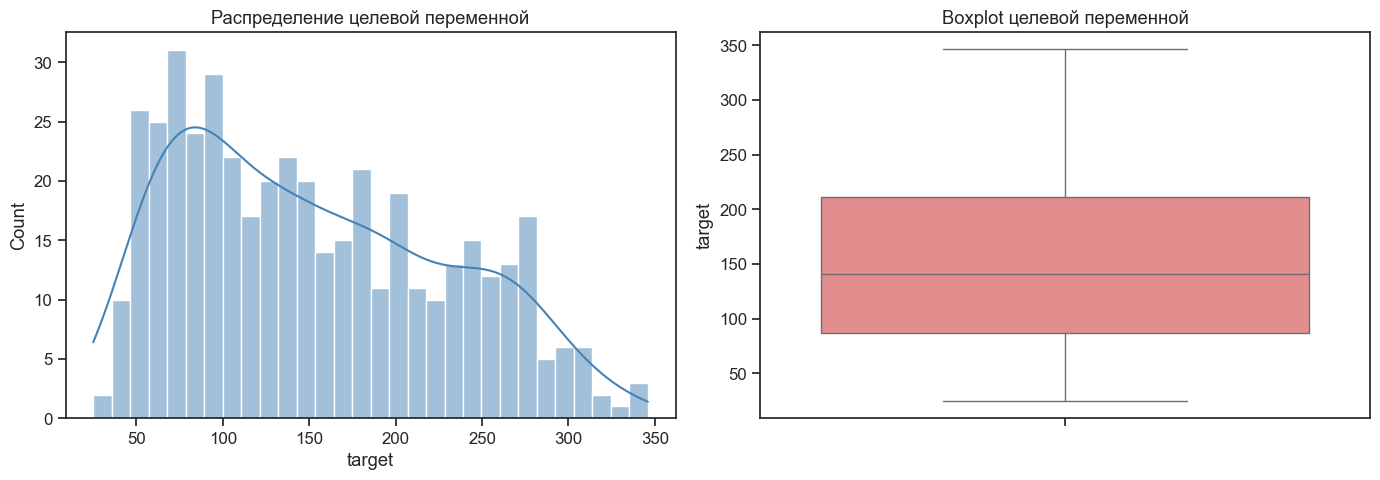

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Гистограмма
sns.histplot(data=df, x='target', bins=30, kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('Распределение целевой переменной')
axes[0].set_xlabel('target')

# Boxplot
sns.boxplot(data=df, y='target', ax=axes[1], color='lightcoral')
axes[1].set_title('Boxplot целевой переменной')

plt.tight_layout()
plt.show()

In [7]:
# Основные метрики целевой переменной
print(f"Среднее значение target: {df['target'].mean():.2f}")
print(f"Медиана target: {df['target'].median():.2f}")
print(f"Стандартное отклонение: {df['target'].std():.2f}")
print(f"Минимум: {df['target'].min():.2f}, Максимум: {df['target'].max():.2f}")

Среднее значение target: 152.13
Медиана target: 140.50
Стандартное отклонение: 77.09
Минимум: 25.00, Максимум: 346.00


# 4. Визуальное исследование данных

### Scatter plots: взаимосвязь признаков с target

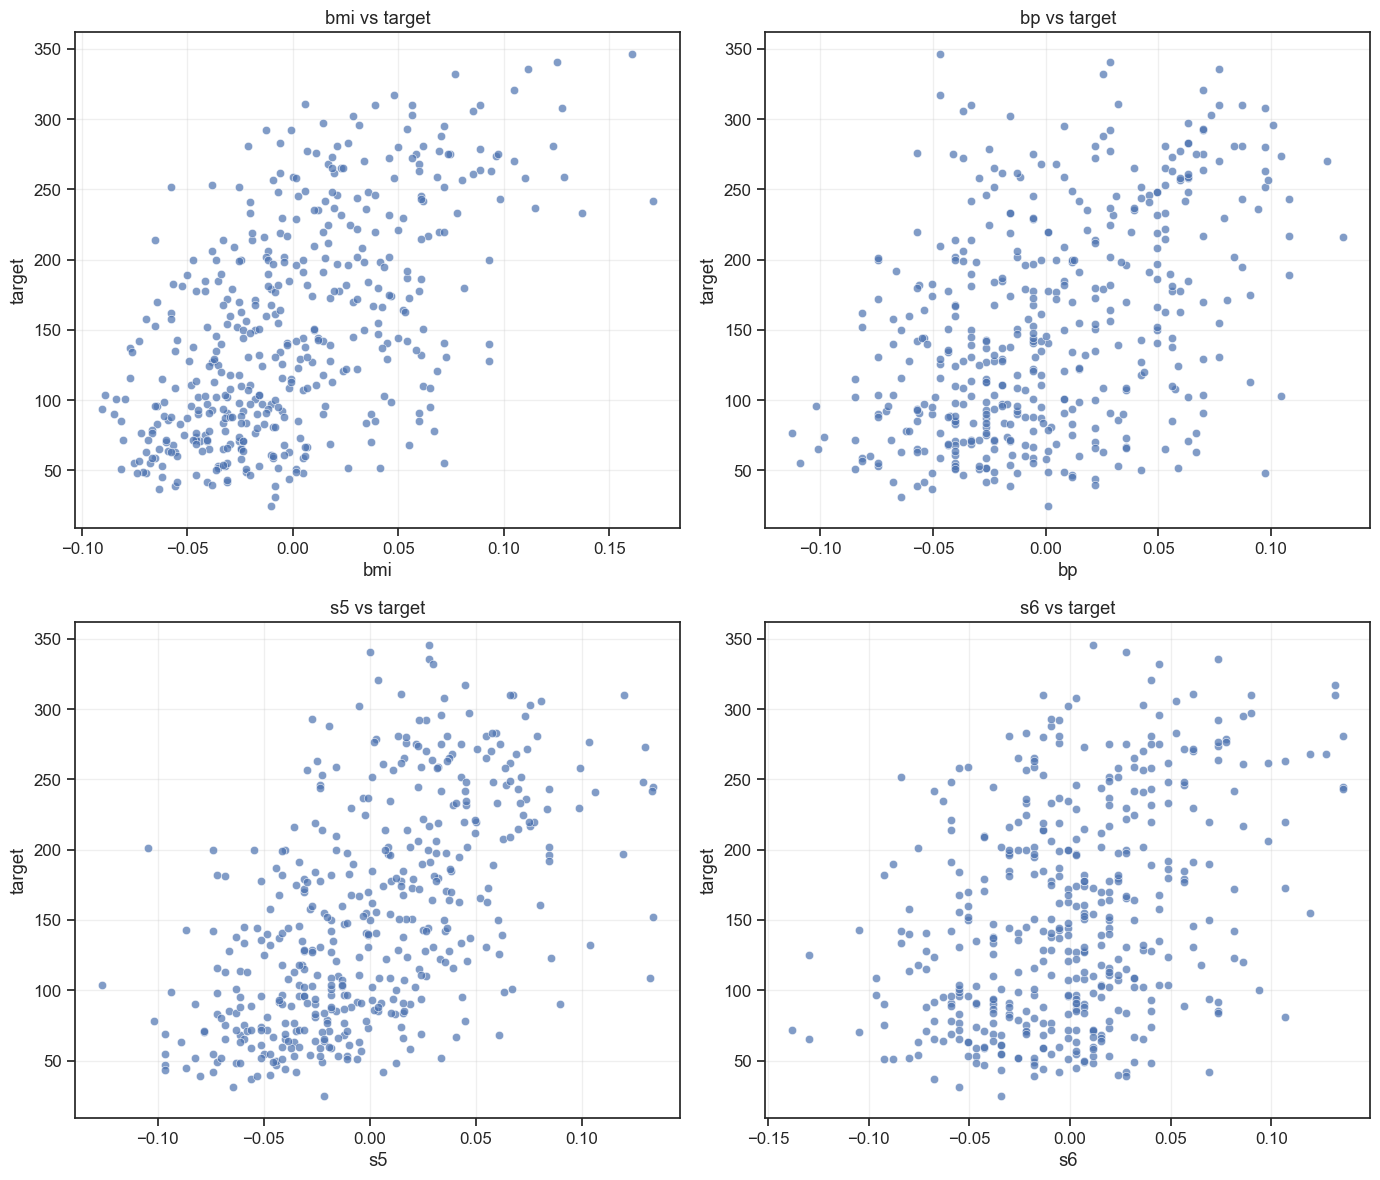

In [8]:
# Выбор наиболее интересных признаков для визуализации
features_to_plot = ['bmi', 'bp', 's5', 's6']

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.ravel()

for idx, feature in enumerate(features_to_plot):
    sns.scatterplot(
        data=df,
        x=feature,
        y='target',
        ax=axes[idx],
        alpha=0.7,
        edgecolor='w',
        linewidth=0.5
    )
    axes[idx].set_title(f'{feature} vs target')
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Гистограммы распределения признаков

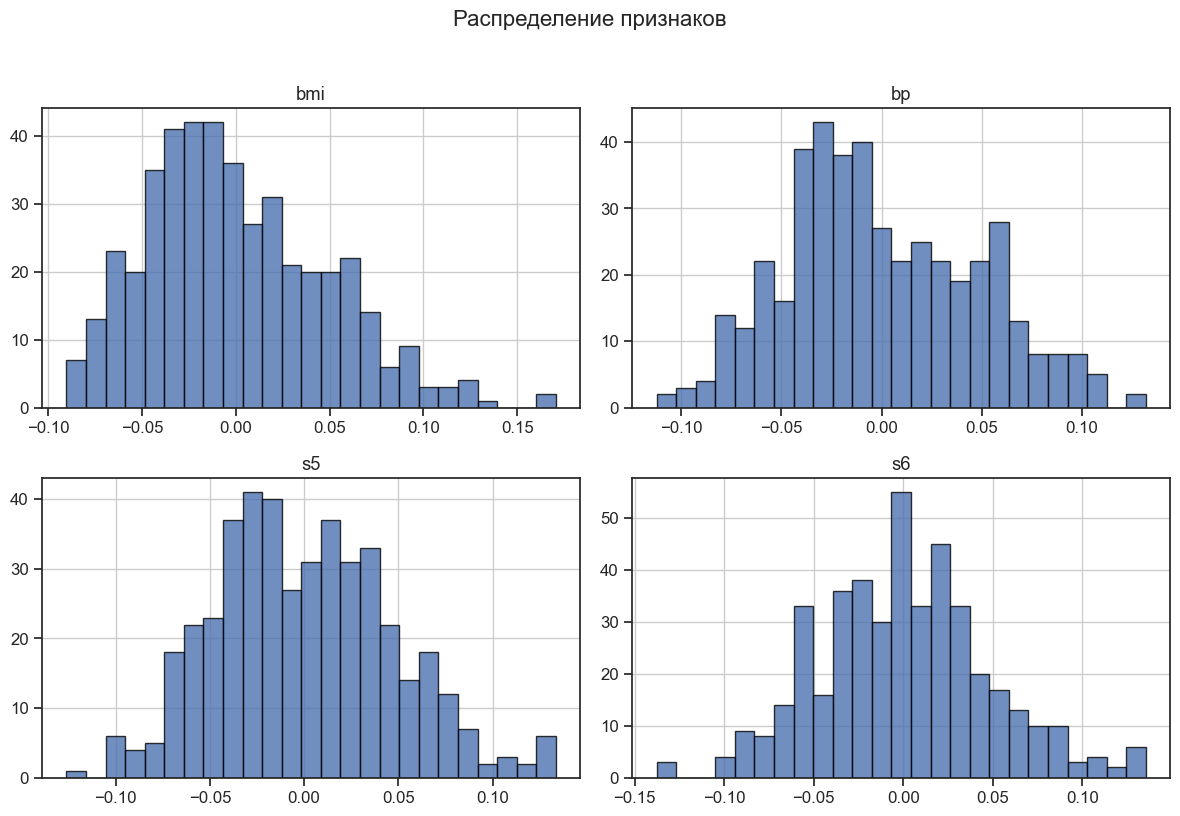

In [9]:
# Распределение числовых признаков
df[features_to_plot].hist(bins=25, figsize=(12, 8), edgecolor='black', alpha=0.8)
plt.suptitle('Распределение признаков', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

### Jointplot: совместное распределение двух признаков

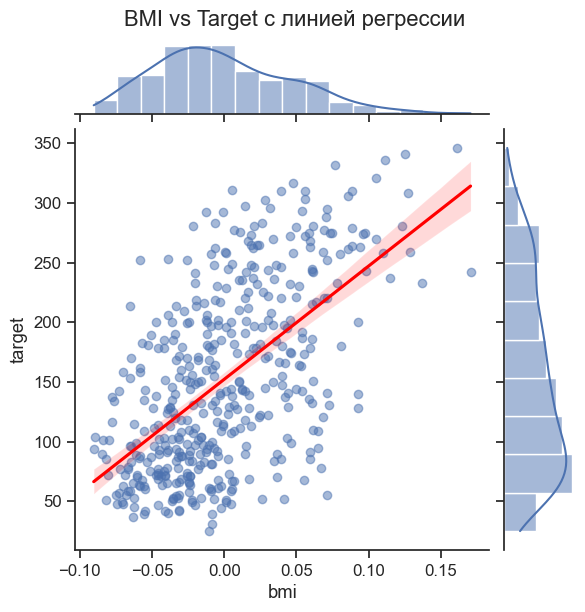

In [10]:
# Jointplot с регрессионной линией
sns.jointplot(
    data=df,
    x='bmi',
    y='target',
    kind='reg',
    scatter_kws={'alpha': 0.5},
    line_kws={'color': 'red'}
)
plt.suptitle('BMI vs Target с линией регрессии', y=1.02)
plt.show()

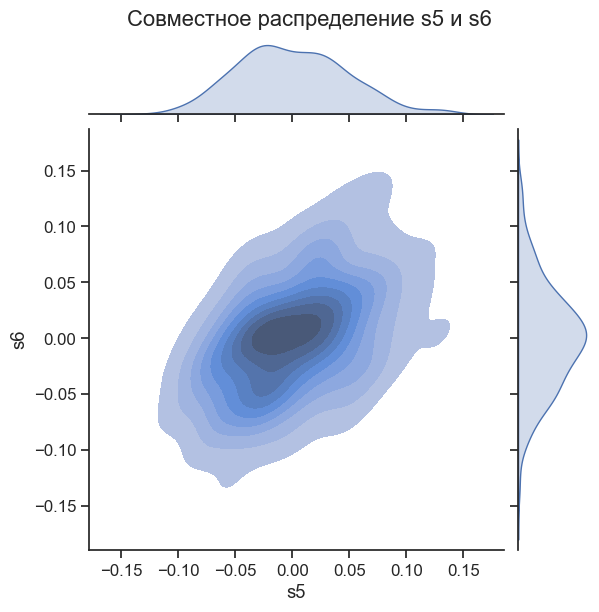

In [11]:
# Jointplot с плотностью распределения (kde)
sns.jointplot(data=df, x='s5', y='s6', kind='kde', fill=True)
plt.suptitle('Совместное распределение s5 и s6', y=1.02)
plt.show()

### Pairplot: попарные взаимосвязи (выборка признаков)

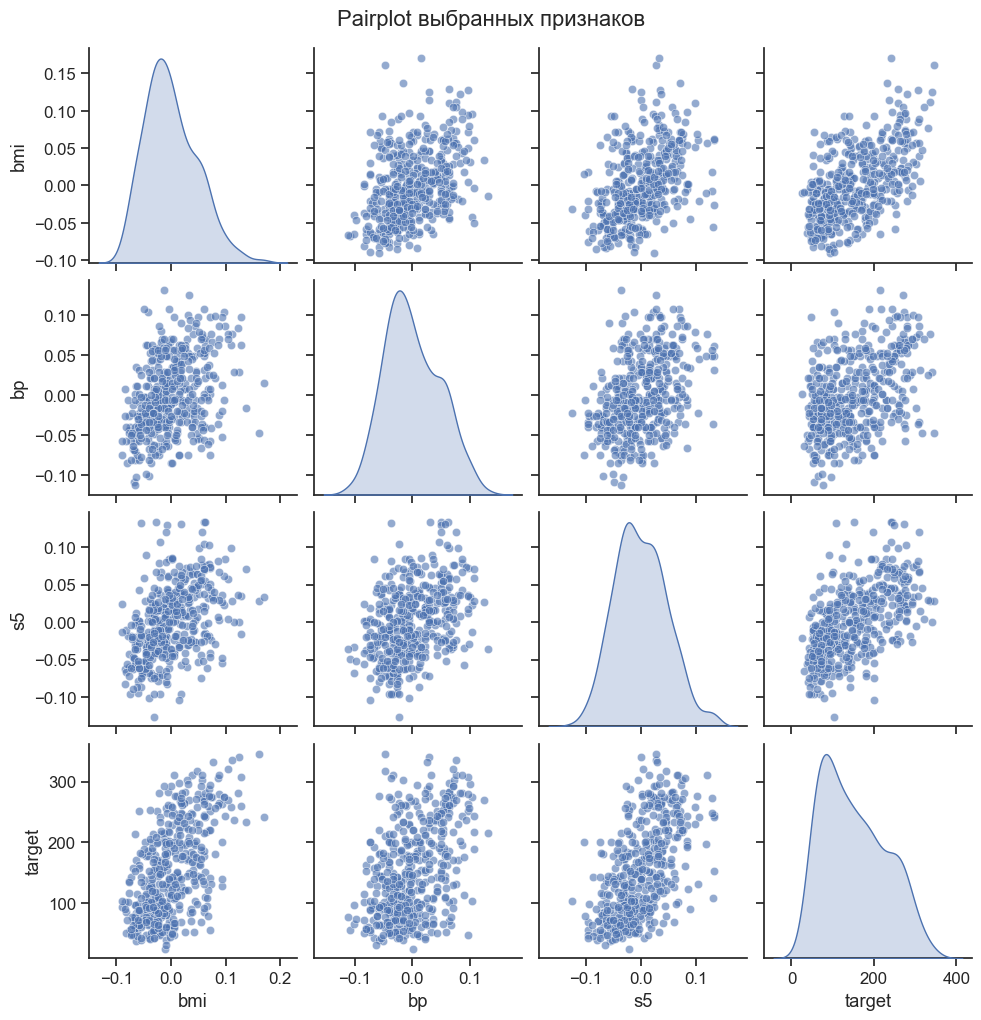

In [12]:
# Pairplot для подмножества признаков + target
subset_cols = ['bmi', 'bp', 's5', 'target']
sns.pairplot(df[subset_cols], diag_kind='kde', plot_kws={'alpha': 0.6})
plt.suptitle('Pairplot выбранных признаков', y=1.02)
plt.show()

### Boxplot: анализ распределения по категориям

C:\Users\Mi\AppData\Local\Temp\ipykernel_14004\2837095419.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='sex', y='target', palette='Set2')


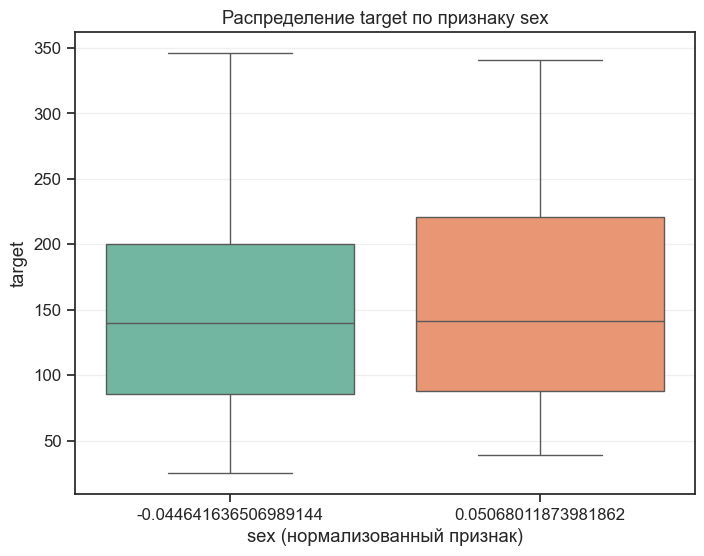

In [17]:
# Boxplot для анализа влияния пола на целевую переменную
# Примечание: sex в этом датасете уже закодирован численно
plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x='sex', y='target', palette='Set2')
plt.title('Распределение target по признаку sex')
plt.xlabel('sex (нормализованный признак)')
plt.ylabel('target')
plt.grid(True, alpha=0.3, axis='y')
plt.show()

### Violin plot: плотность распределения

C:\Users\Mi\AppData\Local\Temp\ipykernel_14004\1628316707.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='bmi_group', y='target', ax=axes[1], palette='muted')


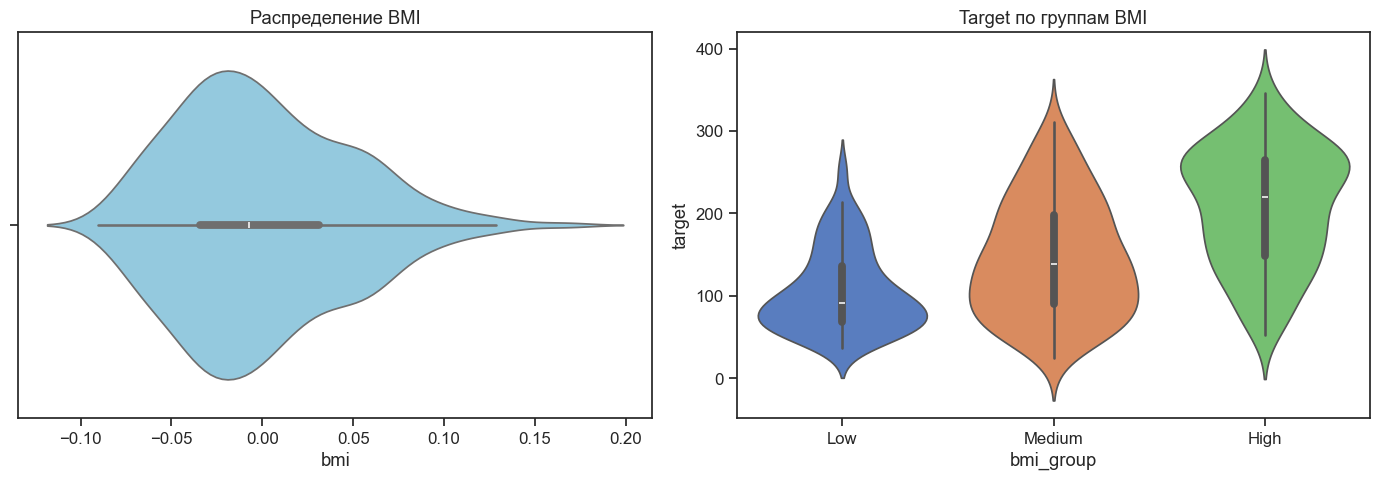

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Violin plot для bmi
sns.violinplot(data=df, x='bmi', ax=axes[0], color='skyblue')
axes[0].set_title('Распределение BMI')

# Violin plot для target с группировкой по медиане bmi
df['bmi_group'] = pd.qcut(df['bmi'], q=3, labels=['Low', 'Medium', 'High'])
sns.violinplot(data=df, x='bmi_group', y='target', ax=axes[1], palette='muted')
axes[1].set_title('Target по группам BMI')

plt.tight_layout()
plt.show()

# Убираем вспомогательный признак
df.drop('bmi_group', axis=1, inplace=True)

# 5. Анализ корреляции признаков

### Матрица корреляций (Pearson)

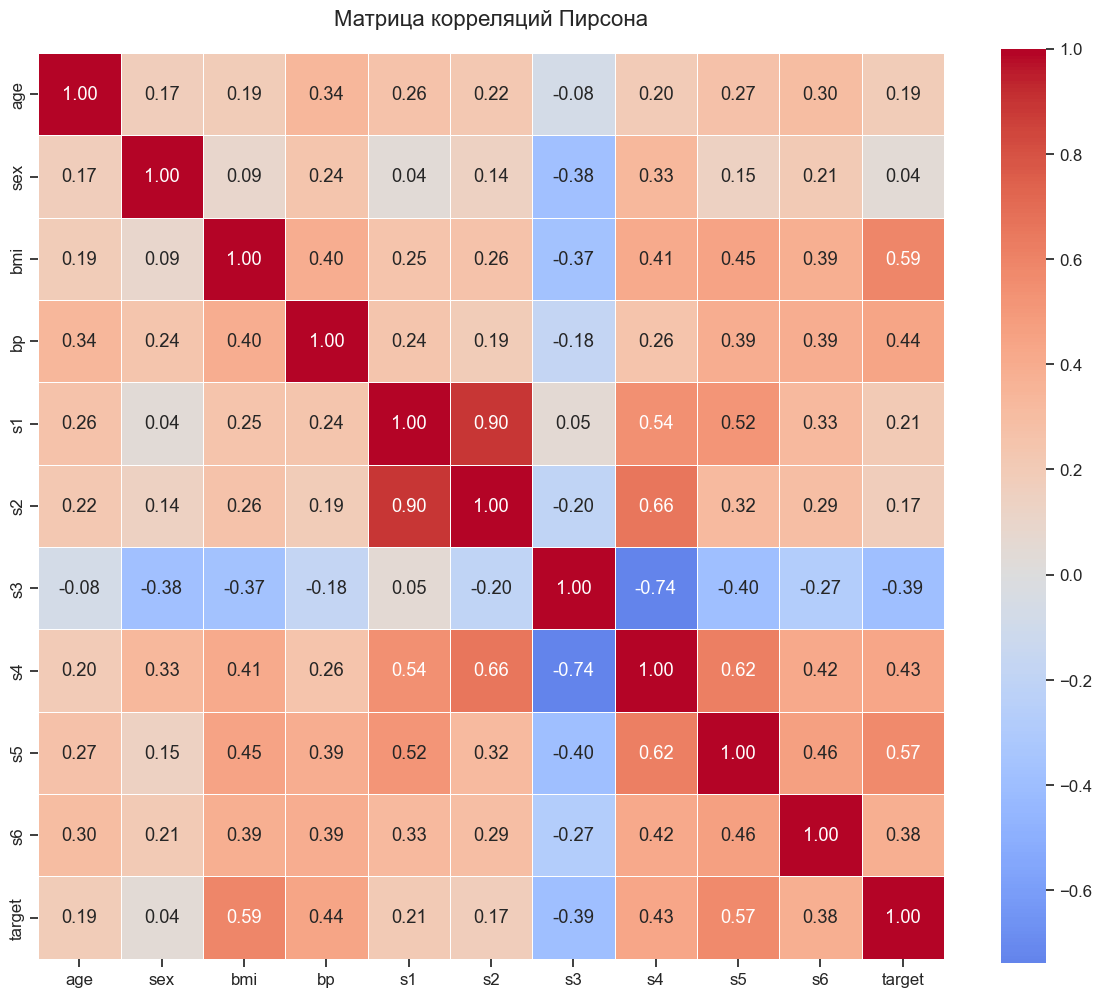

In [19]:
# Вычисление корреляционной матрицы
corr_matrix = df.corr(method='pearson')

# Визуализация heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    square=True,
    linewidths=0.5
)
plt.title('Матрица корреляций Пирсона', fontsize=16, pad=20)
plt.tight_layout()
plt.show()

### Топ-10 наиболее коррелирующих с target признаков

In [20]:
# Корреляция с целевой переменной
target_corr = corr_matrix['target'].drop('target').sort_values(ascending=False)

print("Корреляция признаков с target (по убыванию):")
print("-" * 40)
for feature, corr_val in target_corr.items():
    print(f"{feature:6s} : {corr_val:+.3f}")

Корреляция признаков с target (по убыванию):
----------------------------------------
bmi    : +0.586
s5     : +0.566
bp     : +0.441
s4     : +0.430
s6     : +0.382
s1     : +0.212
age    : +0.188
s2     : +0.174
sex    : +0.043
s3     : -0.395


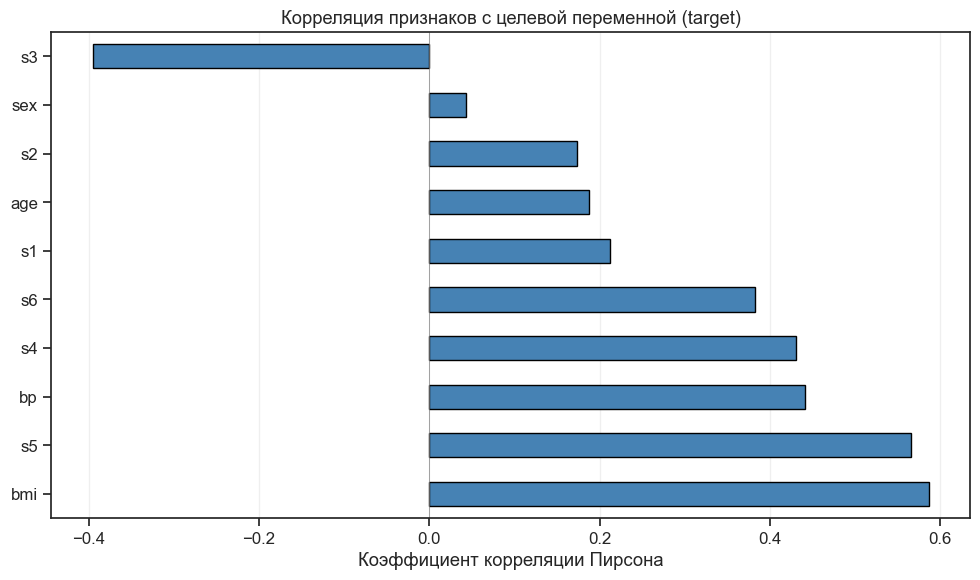

In [26]:
# 1. Создаём Series корреляций, сразу удаляя самокорреляцию target
target_corr = corr_matrix['target'].drop('target').sort_values(ascending=False)

# 2. Визуализируем БЕЗ повторного drop()
plt.figure(figsize=(10, 6))
target_corr.plot(
    kind='barh',
    color='steelblue',
    edgecolor='black'
)
plt.xlabel('Коэффициент корреляции Пирсона')
plt.title('Корреляция признаков с целевой переменной (target)')
plt.grid(True, alpha=0.3, axis='x')
plt.axvline(x=0, color='gray', linewidth=0.5)
plt.tight_layout()
plt.show()

### Сравнение методов корреляции

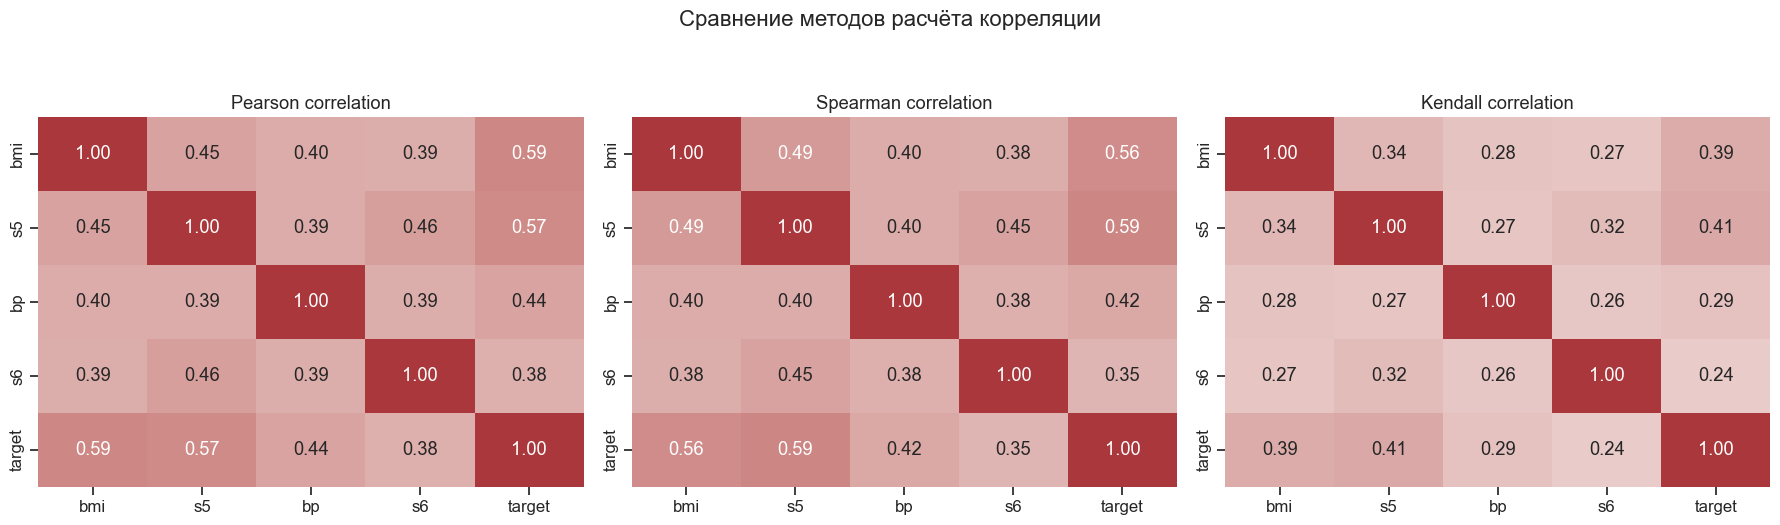

In [23]:
# Сравнение Pearson, Spearman и Kendall для ключевых признаков
methods = ['pearson', 'spearman', 'kendall']
features = ['bmi', 's5', 'bp', 's6']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, method in enumerate(methods):
    corr = df[features + ['target']].corr(method=method)
    sns.heatmap(
        corr,
        annot=True,
        fmt='.2f',
        cmap='vlag',
        center=0,
        ax=axes[idx],
        cbar=False
    )
    axes[idx].set_title(f'{method.capitalize()} correlation')

plt.suptitle('Сравнение методов расчёта корреляции', fontsize=16, y=1.05)
plt.tight_layout()
plt.show()

### Выделение сильных корреляций

In [24]:
# Функция для выделения сильных корреляций
def highlight_strong_corr(corr_df, threshold=0.5):
    strong_corr = []
    for i in range(len(corr_df.columns)):
        for j in range(i+1, len(corr_df.columns)):
            if abs(corr_df.iloc[i, j]) > threshold:
                strong_corr.append({
                    'feature1': corr_df.index[i],
                    'feature2': corr_df.columns[j],
                    'correlation': corr_df.iloc[i, j]
                })
    return pd.DataFrame(strong_corr).sort_values('correlation', key=abs, ascending=False)

# Находим сильные корреляции
strong_corr = highlight_strong_corr(corr_matrix, threshold=0.5)
print("Сильные корреляции (|r| > 0.5):")
print(strong_corr.to_string(index=False))

Сильные корреляции (|r| > 0.5):
feature1 feature2  correlation
      s1       s2     0.896663
      s3       s4    -0.738493
      s2       s4     0.659817
      s4       s5     0.617859
     bmi   target     0.586450
      s5   target     0.565883
      s1       s4     0.542207
      s1       s5     0.515503
